# SINDy Simplicial Complex Check & Plotting
This notebook verifies whether predicted triangles are fully contained within the predicted 1-skeleton (edges) and plots the generated simplicial complex.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Polygon

from sindy import SindyArgs, process_data_in_windows

In [ ]:
# Load actual datastream (or generate a dummy one for testing)
# You can point this to `polynomial_network_v2_high_interaction.csv` if needed:
CSV_FILE = 'polynomial_network_v2_high_interaction.csv'
data_df = pd.read_csv(CSV_FILE, header=None)
data_raw = data_df.values.astype(np.float64)

# Remove degenerate channels just as before
data_raw = data_raw[:, np.ptp(data_raw, axis=0) > 1e-12].T
# data_raw is now shape (N, T) -> [nodes, channels]
print(f"Data shape [[nodes, channels]]: {data_raw.shape}")

Data shape [[nodes, channels]]: (10, 6400)


In [ ]:
from sindy import SindyArgs

# Determine window length to split data into 5 windows
num_windows = 5
win_sg = 29
trim = win_sg - 1 # The preprocessing step trims this many samples off the edges to avoid artifacts
win_len = (data_raw.shape[1] - trim) // num_windows

# Initialize arguments
args = SindyArgs(
    win_len=win_len,
    stride=win_len,
    d_max=2,
    simpl_rho=1.0,
    scale=1.0,
    tau2_q=0.50, # fallback quantile threshold for edge selection
    tau3_q=0.50, # fallback quantile threshold for triangle selection
)

print(f"Data will be split into {num_windows} windows of length {win_len}.")

# Process data
print("Starting processing over windows...")
results = process_data_in_windows(data_raw, args)
#node features, edge weights, triangle weights, hodge laplacian
print(f"Processed {len(results)} windows.")

Data will be split into 5 windows of length 1274.
Starting processing over windows...
Processed 5 windows.



TEMPORAL CHANGES SUMMARY

Transition Window 0 -> 1:
  Edges Added   (+6): [frozenset({2, 5}), frozenset({0, 5}), frozenset({1, 5}), frozenset({8, 5}), frozenset({2, 7}), frozenset({4, 7})]
  Edges Dropped (-6): [frozenset({8, 2}), frozenset({1, 9}), frozenset({9, 3}), frozenset({8, 3}), frozenset({8, 1}), frozenset({1, 3})]
  Tris Added    (+2): [frozenset({4, 5, 6}), frozenset({4, 5, 7})]
  Tris Dropped  (-9): [frozenset({1, 2, 9}), frozenset({9, 2, 3}), frozenset({0, 2, 3}), frozenset({9, 5, 7}), frozenset({8, 9, 2}), frozenset({8, 6, 7}), frozenset({8, 2, 3}), frozenset({8, 1, 9}), frozenset({8, 1, 2})]

Transition Window 1 -> 2:
  Edges Added   (+6): [frozenset({9, 6}), frozenset({1, 4}), frozenset({3, 6}), frozenset({3, 5}), frozenset({0, 7}), frozenset({1, 3})]
  Edges Dropped (-6): [frozenset({4, 6}), frozenset({2, 5}), frozenset({0, 5}), frozenset({1, 5}), frozenset({2, 7}), frozenset({5, 7})]
  Tris Added    (+5): [frozenset({0, 2, 3}), frozenset({8, 5, 6}), frozenset({8, 9, 

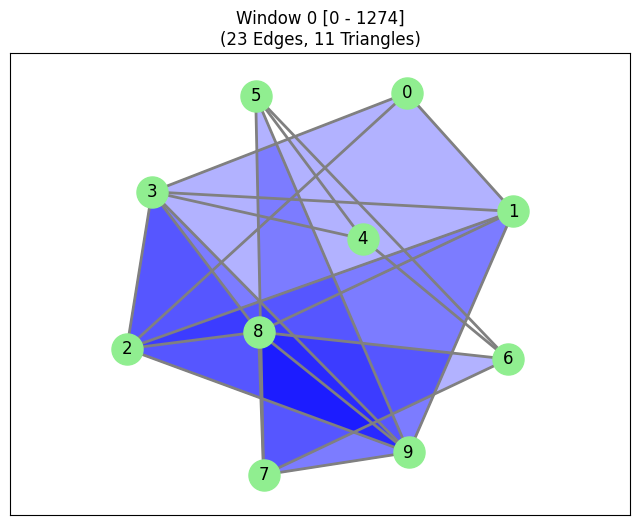

In [25]:
import matplotlib.animation as animation
from IPython.display import HTML

# Determine fixed positions for all possible nodes
n_nodes = data_raw.shape[0]
G_full = nx.complete_graph(n_nodes)
# Use a spring layout on the complete graph to get nicely spaced fixed positions
fixed_pos = nx.spring_layout(G_full, seed=42) 

# Track temporal changes
all_edges = []
all_tris = []
for i, res in enumerate(results):
    all_edges.append(set(res["edges"]))
    all_tris.append(set(res["triangles"]))

print("\n" + "="*50)
print("TEMPORAL CHANGES SUMMARY")
print("="*50)

for i in range(1, len(results)):
    dropped_edges = all_edges[i-1] - all_edges[i]
    new_edges = all_edges[i] - all_edges[i-1]
    
    dropped_tris = all_tris[i-1] - all_tris[i]
    new_tris = all_tris[i] - all_tris[i-1]
    
    print(f"\nTransition Window {i-1} -> {i}:")
    print(f"  Edges Added   (+{len(new_edges)}): {list(new_edges)}")
    print(f"  Edges Dropped (-{len(dropped_edges)}): {list(dropped_edges)}")
    print(f"  Tris Added    (+{len(new_tris)}): {list(new_tris)}")
    print(f"  Tris Dropped  (-{len(dropped_tris)}): {list(dropped_tris)}")


# --- Create Animation ---
fig, ax = plt.subplots(figsize=(8, 6))

def update(frame):
    ax.clear()
    res = results[frame]
    edges = res["edges"]
    tris = res["triangles"]
    closed_tris = res["closed_triangles"]
    
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))
    for e in edges:
        u, v = list(e)
        G.add_edge(u, v)
        
    for ind, tri in enumerate(tris):
        nodes = list(tri)
        if all(n in fixed_pos for n in nodes):
            polygon = np.array([fixed_pos[n] for n in nodes])
            color = 'blue' if tri in closed_tris else 'red'
            alpha = 0.3 if tri in closed_tris else 0.5
            patch = Polygon(polygon, closed=True, color=color, alpha=alpha)
            ax.add_patch(patch)

    nx.draw_networkx_nodes(G, fixed_pos, ax=ax, node_color='lightgreen', node_size=500)
    nx.draw_networkx_edges(G, fixed_pos, ax=ax, edge_color='gray', width=2)
    nx.draw_networkx_labels(G, fixed_pos, ax=ax, font_size=12)
    
    ax.set_title(f"Window {frame} [{res['window_start']} - {res['window_end']}]\n({len(edges)} Edges, {len(tris)} Triangles)")
    ax.axis('equal')

anim = animation.FuncAnimation(fig, update, frames=len(results), interval=1500, repeat=True)

# Display the animation inline
HTML(anim.to_jshtml())